# Step 6 Test: Diagonal Mass Matrix for `STAGE3_MASS_COSMO_BLOCK`
This notebook only reads an existing posterior `.nc` file and computes a diagonal-only mass matrix estimate for `STAGE3_MASS_COSMO_BLOCK` using the site ordering from `WFI2033/Step_6_stardm_model_imaging_only_to_hmc.py`.

In [1]:
import os
os.environ['HDF5_USE_FILE_LOCKING'] = 'FALSE'

import numpy as np
import arviz as az
import matplotlib.pyplot as plt
from pathlib import Path


In [2]:
def fmt_sig2(x):
    x = float(x)
    if not np.isfinite(x):
        return str(x)
    return format(x, '.2g')


## Dense-Mass Site Blocks
These names follow `WFI2033/Step_6_stardm_model_imaging_only_to_hmc.py`.

In [3]:
STAGE3_MASS_COSMO_BLOCK = (
    'm2l_ratio',
    'm2l_ratio_slope',
    'kappa_s_halo',
    'gammain_halo',
    'e_halo',
    'Rs_halo',
    'center_halo',
    'gamma_sheer_halo',
    'theta_E_g1',
    'theta_E_g2',
    'kappa_ext',
)

print('Using block:')
print('  STAGE3_MASS_COSMO_BLOCK =', STAGE3_MASS_COSMO_BLOCK)


Using block:
  STAGE3_MASS_COSMO_BLOCK = ('m2l_ratio', 'm2l_ratio_slope', 'kappa_s_halo', 'gammain_halo', 'e_halo', 'Rs_halo', 'center_halo', 'gamma_sheer_halo', 'theta_E_g1', 'theta_E_g2', 'kappa_ext')


## Read External Posterior `.nc`
If the external posterior stores cosmology as `cosmo_vec`, this notebook maps `cosmo_vec[0] -> omega_m_cosmo` and `cosmo_vec[1] -> H0_cosmo` so the output matches `STAGE3_MASS_COSMO_BLOCK`.

In [4]:
POSTERIOR_NC_PATH = Path(
    '/mnt/lustre/tianli/quasar_hmc/'
    'WFI2033_ss=2_inferh0_step6_imaging_only_20260413_19/'
    'WFI2033_all_ss=2_inferh0_step6_imaging_only.nc'
)
MAX_POSTERIOR_SAMPLES = None  # set an integer for a faster smoke test
POSTERIOR_SAMPLE_SEED = 12345
EXCLUDE_CHAINS = [2, 3]

needed_vars = sorted(set(STAGE3_MASS_COSMO_BLOCK))
posterior_idata = az.from_netcdf(POSTERIOR_NC_PATH)
posterior_ds_full = posterior_idata.posterior
posterior_vars_full = set(posterior_ds_full.data_vars)
posterior_vars_to_load = [v for v in needed_vars if v in posterior_vars_full]

# fallback for files that store cosmology in cosmo_vec instead of omega_m_cosmo / H0_cosmo
if 'omega_m_cosmo' not in posterior_vars_full and 'H0_cosmo' not in posterior_vars_full and 'cosmo_vec' in posterior_vars_full:
    posterior_vars_to_load.append('cosmo_vec')

posterior_ds = posterior_ds_full[posterior_vars_to_load].load()
posterior_vars = set(posterior_ds.data_vars)

print('using posterior file:', POSTERIOR_NC_PATH.name)
print('loaded vars:', sorted(posterior_vars))
print('posterior sizes:', dict(posterior_ds.sizes))
print('exclude chains:', EXCLUDE_CHAINS)


using posterior file: WFI2033_all_ss=2_inferh0_step6_imaging_only.nc
loaded vars: ['Rs_halo', 'center_halo', 'e_halo', 'gamma_sheer_halo', 'gammain_halo', 'kappa_ext', 'kappa_s_halo', 'm2l_ratio', 'm2l_ratio_slope', 'theta_E_g1', 'theta_E_g2']
posterior sizes: {'chain': 6, 'draw': 12000, 'center_halo_dim_0': 2, 'Lens mass vectors - [2]': 2, 'Lens mass g1 scalers - [1]': 1, 'Lens mass g2 scalers - [1]': 1}
exclude chains: [2, 3]


## Diagonal-Only Estimate for `STAGE3_MASS_COSMO_BLOCK`
This computes `std`, `mass_diag = std^2`, and `inverse_mass_diag = 1/std^2` for the mass+cosmology block after dropping chain 2 and 3.

In [5]:
target_sites = list(STAGE3_MASS_COSMO_BLOCK)


def get_site_array(ds, site_name):
    if site_name in ds.data_vars:
        return np.asarray(ds[site_name].values, dtype=float)
    if site_name == 'omega_m_cosmo' and 'cosmo_vec' in ds.data_vars:
        return np.asarray(ds['cosmo_vec'].values[..., 0], dtype=float)
    if site_name == 'H0_cosmo' and 'cosmo_vec' in ds.data_vars:
        return np.asarray(ds['cosmo_vec'].values[..., 1], dtype=float)
    raise KeyError(f'Missing posterior site: {site_name}')


def per_component_names_and_values(site_values, group):
    names = []
    values = []
    for site_name in group:
        arr = np.asarray(site_values[site_name], dtype=float)
        if arr.shape == ():
            names.append(site_name)
            values.append(float(arr))
        else:
            flat = arr.reshape(-1)
            for i, v in enumerate(flat):
                suffix = '[0]' if arr.shape == (1,) else f'[{i}]'
                names.append(f'{site_name}{suffix}')
                values.append(float(v))
    return names, np.asarray(values, dtype=float)


missing_sites = []
for site_name in target_sites:
    try:
        _ = get_site_array(posterior_ds, site_name)
    except KeyError:
        missing_sites.append(site_name)
if missing_sites:
    raise KeyError(f'External posterior is missing required sites: {missing_sites}')

n_chain = int(posterior_ds.sizes['chain'])
n_draw = int(posterior_ds.sizes['draw'])
keep_chains = [c for c in range(n_chain) if c not in EXCLUDE_CHAINS]
sample_pairs = np.array([(c, d) for c in keep_chains for d in range(n_draw)], dtype=int)
if MAX_POSTERIOR_SAMPLES is not None and MAX_POSTERIOR_SAMPLES < len(sample_pairs):
    rng = np.random.default_rng(POSTERIOR_SAMPLE_SEED)
    keep = rng.choice(len(sample_pairs), size=MAX_POSTERIOR_SAMPLES, replace=False)
    sample_pairs = sample_pairs[keep]

print('kept chains:', keep_chains)
print('selected posterior samples:', len(sample_pairs))

diag_names = None
diag_rows = []
for chain_idx, draw_idx in sample_pairs:
    site_values = {
        site_name: get_site_array(posterior_ds, site_name)[int(chain_idx), int(draw_idx)]
        for site_name in target_sites
    }
    names_now, values_now = per_component_names_and_values(site_values, STAGE3_MASS_COSMO_BLOCK)
    if diag_names is None:
        diag_names = names_now
    diag_rows.append(values_now)

diag_rows = np.stack(diag_rows, axis=0)
posterior_std_diag = np.std(diag_rows, axis=0, ddof=1)
posterior_std_diag = np.clip(posterior_std_diag, 1e-12, None)
posterior_mass_diag = posterior_std_diag ** 2
posterior_inverse_mass_diag = 1.0 / posterior_mass_diag

posterior_std_diag_dict = {name: float(val) for name, val in zip(diag_names, posterior_std_diag)}
posterior_mass_diag_dict = {name: float(val) for name, val in zip(diag_names, posterior_mass_diag)}
posterior_inverse_mass_diag_dict = {name: float(val) for name, val in zip(diag_names, posterior_inverse_mass_diag)}

print('Diagonal posterior-space estimate for STAGE3_MASS_COSMO_BLOCK (drop chain 2,3):')
for name, std_val, mass_val, inv_val in zip(diag_names, posterior_std_diag, posterior_mass_diag, posterior_inverse_mass_diag):
    print(f'{name:24s} std={fmt_sig2(std_val):>8s}  mass_diag={fmt_sig2(mass_val):>8s}  inverse_mass_diag={fmt_sig2(inv_val):>8s}')


kept chains: [0, 1, 4, 5]
selected posterior samples: 48000
Diagonal posterior-space estimate for STAGE3_MASS_COSMO_BLOCK (drop chain 2,3):
m2l_ratio                std=    0.12  mass_diag=   0.015  inverse_mass_diag=      66
m2l_ratio_slope          std=   0.071  mass_diag=   0.005  inverse_mass_diag=   2e+02
kappa_s_halo             std=   0.043  mass_diag=  0.0019  inverse_mass_diag= 5.3e+02
gammain_halo             std=    0.09  mass_diag=  0.0081  inverse_mass_diag= 1.2e+02
e_halo[0]                std=  0.0032  mass_diag=   1e-05  inverse_mass_diag= 9.9e+04
e_halo[1]                std=   0.004  mass_diag= 1.6e-05  inverse_mass_diag= 6.2e+04
Rs_halo                  std=     4.4  mass_diag=      20  inverse_mass_diag=   0.051
center_halo[0]           std=  0.0043  mass_diag= 1.9e-05  inverse_mass_diag= 5.3e+04
center_halo[1]           std=  0.0017  mass_diag= 2.7e-06  inverse_mass_diag= 3.6e+05
gamma_sheer_halo[0]      std=  0.0027  mass_diag= 7.2e-06  inverse_mass_diag= 1.4e+05


## Export Variables

In [6]:
print('Available variables for export:')
print('  posterior_std_diag')
print('  posterior_mass_diag')
print('  posterior_inverse_mass_diag')
print('  posterior_std_diag_dict')
print('  posterior_mass_diag_dict')
print('  posterior_inverse_mass_diag_dict')


Available variables for export:
  posterior_std_diag
  posterior_mass_diag
  posterior_inverse_mass_diag
  posterior_std_diag_dict
  posterior_mass_diag_dict
  posterior_inverse_mass_diag_dict


## Visualize `STAGE3_MASS_COSMO_BLOCK` Diagonal Estimates

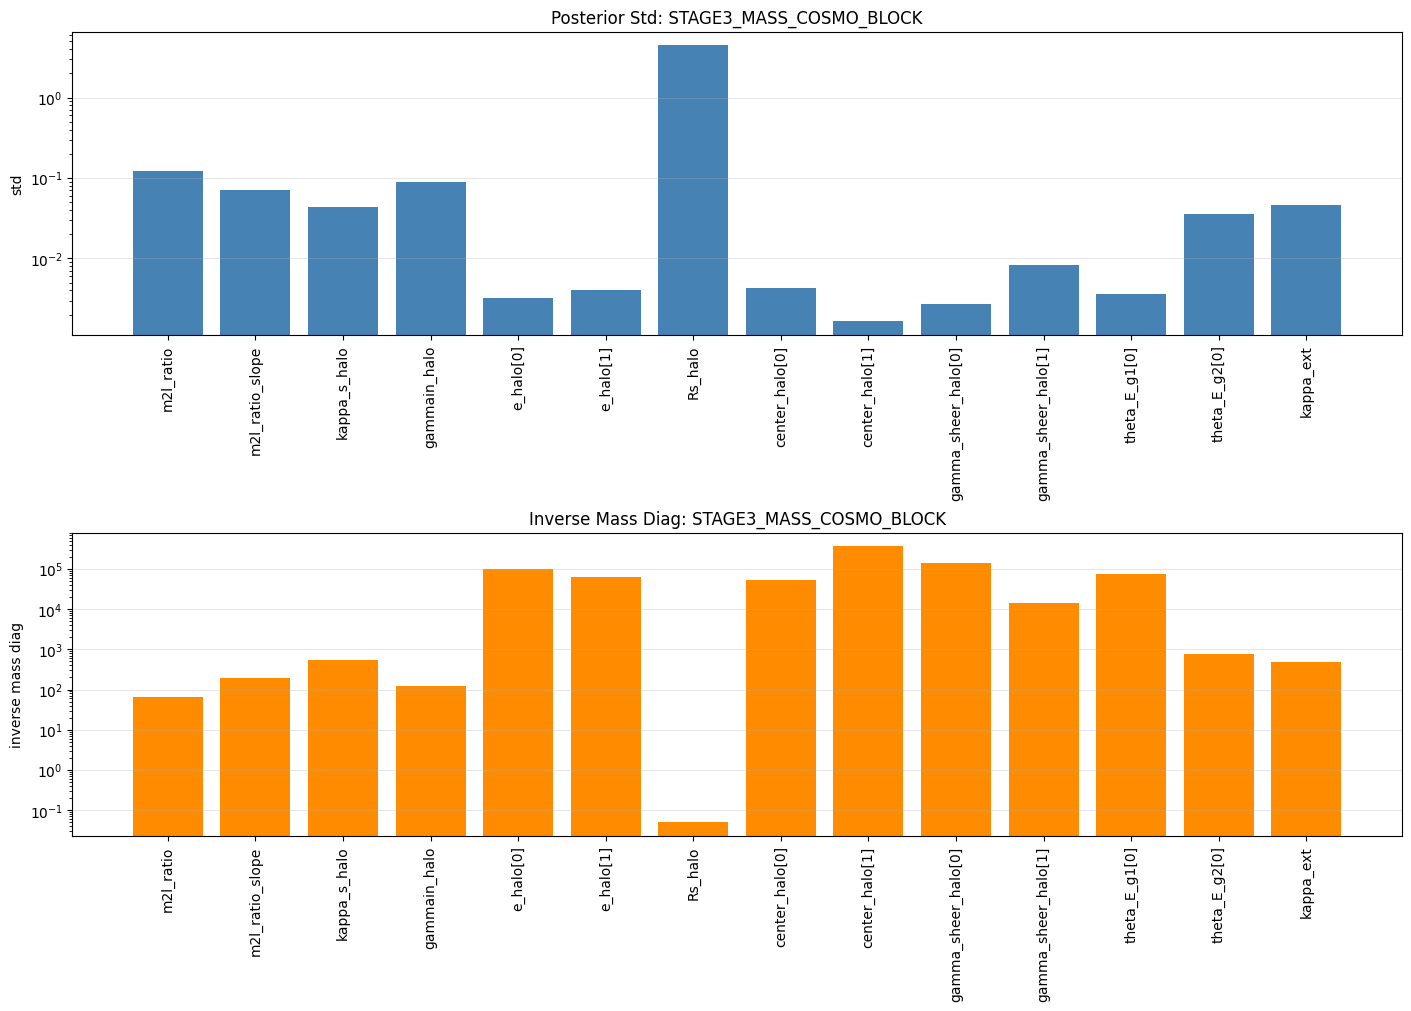

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), constrained_layout=True)

x = np.arange(len(diag_names))

axes[0].bar(x, posterior_std_diag, color='steelblue')
axes[0].set_yscale('log')
axes[0].set_title('Posterior Std: STAGE3_MASS_COSMO_BLOCK')
axes[0].set_ylabel('std')
axes[0].set_xticks(x)
axes[0].set_xticklabels(diag_names, rotation=90)
axes[0].grid(True, axis='y', alpha=0.3)

axes[1].bar(x, posterior_inverse_mass_diag, color='darkorange')
axes[1].set_yscale('log')
axes[1].set_title('Inverse Mass Diag: STAGE3_MASS_COSMO_BLOCK')
axes[1].set_ylabel('inverse mass diag')
axes[1].set_xticks(x)
axes[1].set_xticklabels(diag_names, rotation=90)
axes[1].grid(True, axis='y', alpha=0.3)

plt.show()


In [9]:
# Optional: flat vectors ready to copy into other software
posterior_mass_diag


array([1.51125280e-02, 5.03814956e-03, 1.89023575e-03, 8.11389570e-03,
       1.01379747e-05, 1.62021718e-05, 1.97343396e+01, 1.88348689e-05,
       2.74062026e-06, 7.22994640e-06, 6.95850459e-05, 1.32220835e-05,
       1.27006815e-03, 2.11978055e-03])

In [11]:
posterior_std_diag

array([1.22933022e-01, 7.09799236e-02, 4.34768416e-02, 9.00771652e-02,
       3.18401865e-03, 4.02519214e-03, 4.44233493e+00, 4.33991577e-03,
       1.65548188e-03, 2.68885597e-03, 8.34176515e-03, 3.63621829e-03,
       3.56380155e-02, 4.60410746e-02])